<a href="https://colab.research.google.com/github/kyoseikamada/machinelearning/blob/main/neural-network2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 実装の準備
# ドライブのマウント

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## カレントディレクトリの確認

In [ ]:
!pwd

/content


## カレントディレクトリの移動

In [ ]:
import os

os.chdir('/content/drive/MyDrive/DeepLearning/deep-learning-from-scratch')

In [ ]:
!pwd

/content/drive/MyDrive/DeepLearning/deep-learning-from-scratch


## 画像データの読み込みと表示

5
(784,)
(28, 28)


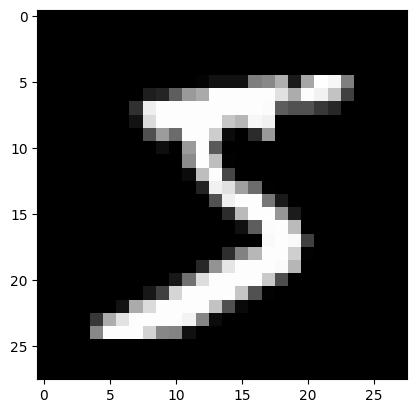

In [ ]:
import sys, os
sys.path.append(os.pardir)

import numpy as np
from dataset.mnist import load_mnist
import matplotlib.pyplot as plt

(x_train, t_train), (x_test, t_test) = load_mnist(
    flatten=True,
    normalize=False
)

img = x_train[0]
label = t_train[0]

print(label)

print(img.shape)

img = img.reshape(28, 28)

print(img.shape)

# 画像表示
plt.imshow(img, cmap='gray')
plt.show()

# 2層ニューラルネットの実装

## 2層クラスの作成

In [ ]:
from re import A
import sys, os
sys.path.append(os.pardir)
from common.functions import *
from common.gradient import numerical_gradient

class TwoLayerNet:

  def __init__(self, input_size, hidden_size, output_size, weight_init_std=0.01):
    # 重みの初期化
    self.params = {}
    self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
    self.params['b1'] = np.zeros(hidden_size)
    self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
    self.params['b2'] = np.zeros(output_size)

  def predict(self, x):
    W1, W2 = self.params['W1'], self.params['W2']
    b1, b2 = self.params['b1'], self.params['b2']

    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    A2 = np.dot(z1, W2) + b2
    y = softmax(A2)

    return y

  def loss(self, x, t):
    y = self.predict(x)

    return cross_entropy_error(y, t)

  def accuracy(self, x, t):
    y = self.predict(x)
    y = np.argmax(y, axis=1)
    t = np.argmax(t, axis=1)

    accuracy = np.sum(y == t) / float(x.shape[0])
    return accuracy

  def numerical_gradient(self, x, t):
    loss_W = lambda W: self.loss(x, t)

    grads = {}
    grads['W1'] = numerical_gradient(loss_W, self.params['W1'])
    grads['b1'] = numerical_gradient(loss_W, self.params['b1'])
    grads['W2'] = numerical_gradient(loss_W, self.params['W2'])
    grads['b2'] = numerical_gradient(loss_W, self.params['b2'])

    return grads

## 画像データの学習を実行

### 通常実行（とんでもなく時間かかる（数値微分だから））

In [ ]:
import numpy as np
from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

train_loss_list = []

# パイパーパラメータ
iters_num = 10000
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.1

network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

for i in range(iters_num):
  batch_mask = np.random.choice(train_size, batch_size)
  x_batch = x_train[batch_mask]
  t_batch = t_train[batch_mask]

  # 勾配の計算
  grad = network.numerical_gradient(x_batch, t_batch)

  # パラメータの更新
  for key in ('W1', 'b1', 'W2', 'b2'):
    network.params[key] -= learning_rate * grad[key]

  # 学習経過の記録
  loss = network.loss(x_batch, t_batch)
  train_loss_list.append(loss)

KeyboardInterrupt: 

### 進捗表示用（こっちはある程度早い（バックプロパゲーション使ってるから））

In [ ]:
import time
from tqdm import tqdm
import numpy as np
from dataset.mnist import load_mnist
from ch04.two_layer_net import TwoLayerNet

start_time = time.time()

train_loss_list = []

# ハイパーパラメータ
iters_num = 10000
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.1

network = TwoLayerNet(
    input_size=784,
    hidden_size=50,
    output_size=10
)

# tqdmで進捗表示
for i in tqdm(range(iters_num), desc="Training"):

    batch_mask = np.random.choice(train_size, batch_size)

    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    # 勾配計算
    # grad = network.numerical_gradient(x_batch, t_batch)
    grad = network.gradient(x_batch, t_batch)

    # パラメータ更新
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]

    # loss計算
    loss = network.loss(x_batch, t_batch)

    train_loss_list.append(loss)

# 終了時間
end_time = time.time()

elapsed_time = end_time - start_time

print(f"\n学習終了")
print(f"経過時間: {elapsed_time:.2f} 秒")

Training: 100%|██████████| 10000/10000 [00:45<00:00, 219.80it/s]


学習終了
経過時間: 45.50 秒


# lossの表示

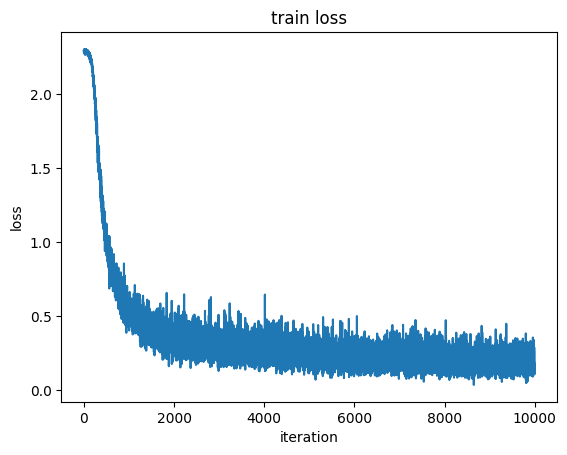

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_loss_list)

plt.xlabel("iteration")
plt.ylabel("loss")
plt.title("train loss")

plt.show()

# 1エポックごとにモデルの評価を追加

In [ ]:
import time
from tqdm import tqdm
import numpy as np
from dataset.mnist import load_mnist
from ch04.two_layer_net import TwoLayerNet

# ハイパーパラメータ
iters_num = 10000
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.1

train_loss_list = []
train_acc_list = []
test_acc_list = []
# 1エポック当たりの繰り返し数
iter_per_epoch = max(train_size / batch_size, 1)

network = TwoLayerNet(
    input_size=784,
    hidden_size=50,
    output_size=10
)

# 開始時間
start_time = time.time()

# tqdmで進捗表示
for i in tqdm(range(iters_num), desc="Training"):

    batch_mask = np.random.choice(train_size, batch_size)

    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    # 勾配計算
    # grad = network.numerical_gradient(x_batch, t_batch)
    grad = network.gradient(x_batch, t_batch)

    # パラメータ更新
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]

    # loss計算
    loss = network.loss(x_batch, t_batch)

    train_loss_list.append(loss)

    # 1エポックごとに認識精度を計算
    if i % iter_per_epoch == 0:
      train_acc = network.accuracy(x_train, t_train)
      test_acc = network.accuracy(x_test, t_test)
      train_acc_list.append(train_acc)
      test_acc_list.append(test_acc)
      print(f"train acc, test acc | {train_acc:.4f}, {test_acc:.4f}")

# 終了時間
end_time = time.time()

elapsed_time = end_time - start_time

print(f"\n学習終了")
print(f"経過時間: {elapsed_time:.2f} 秒")

Training:   0%|          | 14/10000 [00:02<19:38,  8.47it/s] 

train acc, test acc | 0.0992, 0.1009


Training:   7%|▋         | 665/10000 [00:06<01:03, 147.43it/s]

train acc, test acc | 0.7829, 0.7902


Training:  13%|█▎        | 1262/10000 [00:09<00:57, 152.51it/s]

...

train acc, test acc | 0.9459, 0.9441


Training:  97%|█████████▋| 9669/10000 [00:58<00:02, 154.31it/s]

train acc, test acc | 0.9477, 0.9437


Training: 100%|██████████| 10000/10000 [00:59<00:00, 168.72it/s]


学習終了
経過時間: 59.28 秒


# accuracyの表示

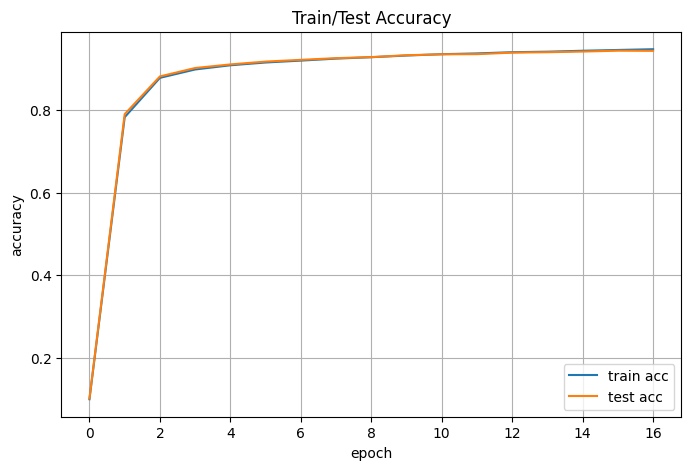

In [ ]:
import matplotlib.pyplot as plt

# エポック数
epochs = range(len(train_acc_list))

# グラフサイズ
plt.figure(figsize=(8, 5))

# train accuracy
plt.plot(
    epochs,
    train_acc_list,
    label='train acc'
)

# test accuracy
plt.plot(
    epochs,
    test_acc_list,
    label='test acc'
)

# 軸ラベル
plt.xlabel('epoch')
plt.ylabel('accuracy')

# タイトル
plt.title('Train/Test Accuracy')

# 凡例
plt.legend()

# グリッド
plt.grid()

# 表示
plt.show()